In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF as NMF_sklearn
from scipy import stats
import copy
from nmf import NMF as NMF_potts

### For test set B
First we plot for the best runs of Dirac-3 vs CP-SAT (this was not there in the paper)

In [2]:
#Getting the variables ready
#Parameters (remember k is called p in the paper)
n = 4
k = 3
m = 8
hist_data_mthread = {'l1':[], 'l2':[]} #will hold rel_error % decrease data for cases when dirac3 was better than cpsat_mthread
what_is_better = {'dirac3':0,'cpsat':0 }
mthread_better = {'l1':copy.deepcopy(what_is_better), 'l2':copy.deepcopy(what_is_better)} #dictionary to hold counts of cases where dirac3 or cpsat mthread was better
hist_data_sthread = {'l1':[], 'l2':[]} #will hold rel_error rel_error % decrease data for cases when dirac3 was better than cpsat_sthread
sthread_better = {'l1':copy.deepcopy(what_is_better), 'l2':copy.deepcopy(what_is_better)} #dictionary to hold counts of cases where dirac3 or cpsat sthread was better

In [3]:
#Note, for CP-SAT, here l1 : sum of abs differences and l2 : sum of squared differences
maxval = 7 #maxval tells you the largest integer per variable (in our case integer variables can take values from 0 to 7)
for i in range(100):
    filepath_basic = "./test_matrices/dirac3_exp4a/size_" + str(n) + "x" + str(m) + "/results/" 
    filename_dirac3 = f'res_mat_4x8_{i}_dirac3_sched_1_potts.npz'
    filepath_dirac3 = filepath_basic + filename_dirac3
    f1 = np.load(filepath_dirac3)
    rel_error_dirac3 = float(f1['rel_error'])
    f1.close()
    rel_error_mthread = {'l1':0.0, 'l2':0.0}
    rel_error_sthread = {'l1':0.0, 'l2':0.0}
    for obj in ['l1','l2']:
        filename_mthread = f'res_mat_4x8_{i}_cpsat_mthread_{obj}_{maxval}.npz'
        filename_sthread = f'res_mat_4x8_{i}_cpsat_sthread_{obj}_{maxval}.npz'
        
        filepath_mthread = filepath_basic + filename_mthread
        filepath_sthread = filepath_basic + filename_sthread


        f2 = np.load(filepath_mthread)
        f3 = np.load(filepath_sthread)
        
        rel_error_mthread[obj] = float(f2['rel_error'])
        rel_error_sthread[obj] = float(f3['rel_error'])

        #Get counter for dirac3 vs mthread (and % decrease if better)
        if rel_error_dirac3 < rel_error_mthread[obj]:
            mthread_better[obj]['dirac3'] += 1
            hist_data_mthread[obj].append( (rel_error_mthread[obj] - rel_error_dirac3)*100/rel_error_mthread[obj])
        elif rel_error_dirac3 > rel_error_mthread[obj]:
            mthread_better[obj]['cpsat'] += 1

        #Get counter for dirac3 vs sthread (and % decrease if better)
        if rel_error_dirac3 < rel_error_sthread[obj]:
            sthread_better[obj]['dirac3'] += 1
            hist_data_sthread[obj].append( (rel_error_sthread[obj] - rel_error_dirac3)*100/rel_error_sthread[obj])
        elif rel_error_dirac3 > rel_error_sthread[obj]:
            sthread_better[obj]['cpsat'] += 1
            

        
        f2.close()
        f3.close()


    

In [4]:
#Cases where one solver did better than the other (Dirac-3 vs CP-SAT)
#For parallel processing (multi thread)
mthread_better

{'l1': {'dirac3': 0, 'cpsat': 100}, 'l2': {'dirac3': 0, 'cpsat': 100}}

In [5]:
#Cases where one solver did better than the other (Dirac-3 vs CP-SAT)
#For serial processing (single thread)
sthread_better

{'l1': {'dirac3': 25, 'cpsat': 75}, 'l2': {'dirac3': 33, 'cpsat': 67}}

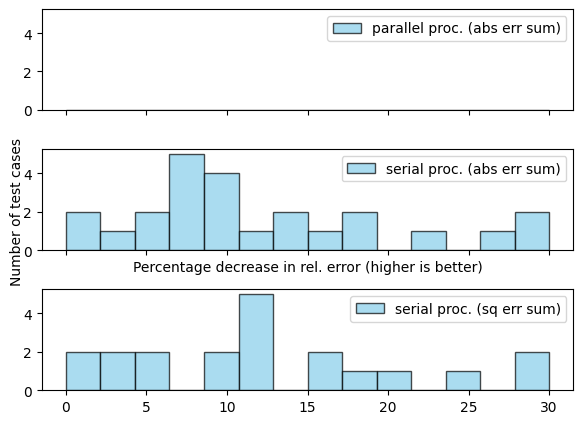

In [6]:
#Plot histograms of the percentage of rel error decrease
#(Top) histogram is empty but is plotted to keep symmetry with the plot from the other test set
fig, ax = plt.subplots(3,1,sharey=True, sharex=True, tight_layout=True)


ax[0].hist(hist_data_mthread['l1'],bins=np.linspace(0,30,15),label="parallel proc. (abs err sum)",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[1].hist(hist_data_sthread['l1'],bins=np.linspace(0,30,15),label="serial proc. (abs err sum)",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[2].hist(hist_data_sthread['l2'],bins=np.linspace(0,30,15),label="serial proc. (sq err sum)",color='skyblue', edgecolor='black', alpha=0.7,density=False)

fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)
fig.text(0.015, 0.5, 'Number of test cases', ha='center', va='center', rotation='vertical')
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
ax[2].legend(loc='upper right')
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax[1].set_xlabel('Percentage decrease in rel. error (higher is better)')
plt.show()

In [7]:
#Most improvement
max(hist_data_sthread['l1'])

31.932352521887214

## Now for median runs (instead of best runs)
Median CP-SAT vs Median Dirac-3 (this made it to the paper)

In [ ]:
#Getting the variables ready
#Parameters (remember k is called p in the paper)
n = 4
k = 3
m = 8

hist_data_mthread = {'l1':[], 'l2':[]} #will hold rel_error % decrease data for cases when dirac3 was better than cpsat_mthread
all_hist_data_mthread = {'l1':[], 'l2':[]} #will hold rel_error % decrease data for all cases (cpsat mthread)
what_is_better = {'dirac3':0,'cpsat':0 }
mthread_better = {'l1':copy.deepcopy(what_is_better), 'l2':copy.deepcopy(what_is_better)} #dictionary to hold counts of cases where dirac3 or cpsat mthread was better
hist_data_sthread = {'l1':[], 'l2':[]} #will hold rel_error rel_error % decrease data for cases when dirac3 was better than cpsat_sthread
all_hist_data_sthread = {'l1':[], 'l2':[]} #will hold rel_error % decrease data for all cases (cpsat sthread)
sthread_better = {'l1':copy.deepcopy(what_is_better), 'l2':copy.deepcopy(what_is_better)} #dictionary to hold counts of cases where dirac3 or cpsat sthread was better

In [11]:
#Important functions to get the median results
def get_expanded_result(counts,energies,soln):
    new_counts = []
    new_energies = []
    new_soln = []
    for i in range(len(counts)):
        for _ in range(counts[i]):
            new_counts.append(1)
            new_energies.append(energies[i])
            new_soln.append(soln[i])
    return new_counts, new_energies, new_soln

def get_closest2median(energies,soln):    
    median_energy = np.median(energies)
    closest_idx = np.argmin(np.abs(energies - median_energy))
    closest_energy = energies[closest_idx]
    closest_soln = copy.deepcopy(soln[closest_idx])
    return median_energy,closest_energy,closest_soln


def get_errors(V,soln,n,k,m,var_dict):
    #First get W and H matrices
    #Get W
    W = np.zeros((n,k))
    H = np.zeros((k,m))
    V_rec = np.zeros((n,m))
    for i in range(n):
        for j in range(k):
                tempwstr = 'w_'+str(i)+","+str(j)
                W[i,j] = soln[var_dict[tempwstr]-1]

        #Get H
        for i in range(k):
            for j in range(m):
                temphstr = 'h_'+str(i)+","+str(j)
                H[i,j] = soln[var_dict[temphstr]-1]

        #Get V_rec
        V_rec = W @ H
    
    abs_error = np.linalg.norm(V - V_rec)
    rel_error = abs_error/np.linalg.norm(V)
    
    return abs_error,rel_error


In [12]:
maxval = 7
apples_to_apples = True #if True compares median dirac3 with median cpsat, else it compares median dirac3 with best cpsat
for i in range(100):
    filepath_basic = "./test_matrices/dirac3_exp4a/size_" + str(n) + "x" + str(m) + "/results/" 
    filename_dirac3 = f'res_mat_4x8_{i}_dirac3_sched_1_potts.npz'
    filepath_dirac3 = filepath_basic + filename_dirac3
    f1 = np.load(filepath_dirac3)
    diracfile = dict(f1)
    f1.close()


    #Setting up the problem to get var_dict (to get W and H and rel_error for median answers)
    filename = 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+".npz"
    filepath = "./test_matrices/dirac3_exp4a/size_" + str(n) + "x" + str(m) + "/" + filename 
    f = np.load(filepath)
    V = f['V']
    f.close()

    #Now for dirac-3
    V = V.astype(float)
    size = (n*k) + (k*m)
    nmf1 = NMF_potts(V,k,size)
    nmf1.encode_problem()

    #Get the unrolled soln and energies - to calculate median
    _, energies, soln = get_expanded_result(diracfile['counts'],diracfile['energies'],diracfile['solutions'])
    median_energy,closest_energy,closest_soln = get_closest2median(energies,soln)

    abs_error_dirac3,rel_error_dirac3 = get_errors(V,closest_soln,n,k,m,nmf1.var_dict)

    if float(diracfile['rel_error']) >= rel_error_dirac3:
        print("Hold up")

    #Now for cpsat results
    rel_error_mthread = {'l1':0.0, 'l2':0.0}
    rel_error_sthread = {'l1':0.0, 'l2':0.0}
    for obj in ['l1','l2']:
        filename_mthread = f'res_mat_4x8_{i}_cpsat_mthread_{obj}_{maxval}.npz'
        filename_sthread = f'res_mat_4x8_{i}_cpsat_sthread_{obj}_{maxval}.npz'
        
        filepath_mthread = filepath_basic + filename_mthread
        filepath_sthread = filepath_basic + filename_sthread


        f2 = np.load(filepath_mthread)
        f3 = np.load(filepath_sthread)
        
        if apples_to_apples == False:
            rel_error_mthread[obj] = float(f2['rel_error'])
            rel_error_sthread[obj] = float(f3['rel_error'])
        else:
            #Taking in the entire list of rel errors
            rel_error_list_mthread = f2['rel_error_cpsat_list']
            rel_error_list_sthread = f3['rel_error_cpsat_list']

            #Getting the rel_error closest to the median for mthread
            median_rel = np.median(rel_error_list_mthread)
            closest_idx = np.argmin(np.abs(rel_error_list_mthread - median_rel))
            rel_error_mthread[obj] = rel_error_list_mthread[closest_idx]

            #Getting the rel_error closest to the median for sthread
            median_rel = np.median(rel_error_list_sthread)
            closest_idx = np.argmin(np.abs(rel_error_list_sthread - median_rel))
            rel_error_sthread[obj] = rel_error_list_sthread[closest_idx]
        
        #Get data into the list that is tracking all improvement and worst cases
        all_hist_data_mthread[obj].append( (rel_error_mthread[obj] - rel_error_dirac3)*100/rel_error_mthread[obj])
        all_hist_data_sthread[obj].append( (rel_error_sthread[obj] - rel_error_dirac3)*100/rel_error_sthread[obj])        


        #Get counter for dirac3 vs mthread (and % decrease if better)
        if rel_error_dirac3 < rel_error_mthread[obj]:
            mthread_better[obj]['dirac3'] += 1
            hist_data_mthread[obj].append( (rel_error_mthread[obj] - rel_error_dirac3)*100/rel_error_mthread[obj])
        elif rel_error_dirac3 > rel_error_mthread[obj]:
            mthread_better[obj]['cpsat'] += 1

        #Get counter for dirac3 vs sthread (and % decrease if better)
        if rel_error_dirac3 < rel_error_sthread[obj]:
            sthread_better[obj]['dirac3'] += 1
            hist_data_sthread[obj].append( (rel_error_sthread[obj] - rel_error_dirac3)*100/rel_error_sthread[obj])
        elif rel_error_dirac3 > rel_error_sthread[obj]:
            sthread_better[obj]['cpsat'] += 1
        
        f2.close()
        f3.close()

C:\Users\User\AppData\Local\Temp\ipykernel_22888\3071748980.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  all_hist_data_mthread[obj].append( (rel_error_mthread[obj] - rel_error_dirac3)*100/rel_error_mthread[obj])
C:\Users\User\AppData\Local\Temp\ipykernel_22888\3071748980.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  all_hist_data_sthread[obj].append( (rel_error_sthread[obj] - rel_error_dirac3)*100/rel_error_sthread[obj])


In [13]:
mthread_better

{'l1': {'dirac3': 0, 'cpsat': 100}, 'l2': {'dirac3': 0, 'cpsat': 100}}

In [14]:
sthread_better

{'l1': {'dirac3': 59, 'cpsat': 41}, 'l2': {'dirac3': 41, 'cpsat': 59}}

In [15]:
#P-value calculation
from math import comb
def p_val(nb,nw):
    agg_p = 0 #aggregator
    for k in range(nb, nb+nw+1):
        agg_p += comb(nb+nw,k) #<--- I think this is the correction version
    agg_p *= (1/2)**(nb+nw)

    return agg_p

In [19]:
print("59 better:",p_val(59,41) )
print("51 better:",p_val(51,49) )
print("300 better:",p_val(300,100) )

59 better: 0.04431304005703379
51 better: 0.46020538130641064
300 better: 1.2959434534860383e-24


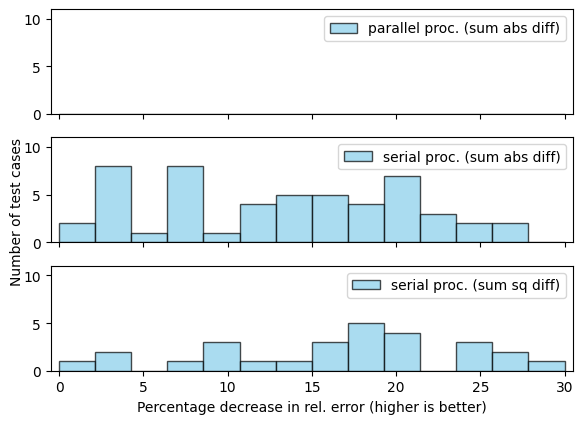

In [16]:
fig, ax = plt.subplots(3,1,sharey=True, sharex=True, tight_layout=True)


ax[0].hist(hist_data_mthread['l1'],bins=np.linspace(0,30,15),label="parallel proc. (sum abs diff)",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[1].hist(hist_data_sthread['l1'],bins=np.linspace(0,30,15),label="serial proc. (sum abs diff)",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[2].hist(hist_data_sthread['l2'],bins=np.linspace(0,30,15),label="serial proc. (sum sq diff)",color='skyblue', edgecolor='black', alpha=0.7,density=False)

fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)
fig.text(0.015, 0.5, 'Number of test cases', ha='center', va='center', rotation='vertical')
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
ax[2].legend(loc='upper right')
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax[0].set_xlim(-0.5,30.5)
ax[1].set_xlim(-0.5,30.5)
ax[2].set_xlim(-0.5,30.5)

ax[0].set_ylim(0,11)
ax[1].set_ylim(0,11)
ax[2].set_ylim(0,11)

ax[0].set_yticks(np.arange(0,11,5))
ax[1].set_yticks(np.arange(0,11,5))
ax[2].set_yticks(np.arange(0,11,5))

ax[2].set_xlabel('Percentage decrease in rel. error (higher is better)')
plt.savefig('plot_exp4_setB.pdf')
plt.show()

In [ ]:
print("Median improvement over CPSAT (sthread L1):",round(np.mean(hist_data_sthread['l1']),4),"%")
print("Median improvement over CPSAT (sthread L2):",round(np.mean(hist_data_sthread['l2']),4),"%")


Median improvement over CPSAT (sthread L1): 15.7392 %
Median improvement over CPSAT (sthread L2): 24.6742 %


In [ ]:
all_hist_data_mthread

{'l1': [-inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf],
 'l2': [-inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -inf,
  -